<figure>
    <picture>
        <source srcset="assets/iita-logo.png" style="max-height: 10rem;">
        <img src="https://raw.githubusercontent.com/Computational-Biology-Aachen/2026-photosynthesis-hackathon-template/refs/heads/main/assets/iita-logo.png" style="max-height: 10rem;">
    </picture>
</figure>

# Cowpea data

This notebook contains example analysis for the cowpea data kindly supplied by the IITA

|                  |                                |
| ---------------- | ------------------------------ |
| **Crop**         | Cowpea (_Vigna unguiculata_)   |
| **Locations**    | Ibadan, Ikenne, Kano (Nigeria) |
| **Years**        | 2020–2022                      |
| **Measurements** | 3,360                          |
| **Genotypes**    | 112 (98 with SNP markers)      |
| **SNP markers**  | 9,210 DArT-Seq                 |
| **Owner**        | Olakunle Sansa (IITA)          |
| **Design**       | 8x14 Alpha Lattice, 3 reps     |

**Experiment:** Multi-environment drought stress trial on cowpea at three IITA locations in Nigeria. Each genotype was measured before and during drought stress across multiple years, giving 10 environments (location x year x stress condition). Data was collected with MultispeQ devices and pre-processed by IITA — this dataset contains computed phenotype values, not raw measurement traces.

**Environments (336 measurements each):**

| ENV | Location | Year | Condition     |
| --- | -------- | ---- | ------------- |
| 1   | Ibadan   | 2020 | Before Stress |
| 2   | Ibadan   | 2021 | Before Stress |
| 3   | Ikenne   | 2020 | Before Stress |
| 4   | Ikenne   | 2021 | Before Stress |
| 5   | Kano     | 2021 | Before Stress |
| 6   | Kano     | 2022 | Before Stress |
| 7   | Ibadan   | 2020 | During Stress |
| 8   | Ibadan   | 2021 | During Stress |
| 9   | Ikenne   | 2021 | During Stress |
| 10  | Kano     | 2021 | During Stress |

**Phenotype columns (measurements table):**

| Column                         | Description                                                 |
| ------------------------------ | ----------------------------------------------------------- |
| `relative_chlorophyll_content` | SPAD-equivalent relative chlorophyll content                |
| `leaf_angle`                   | Leaf angle (degrees)                                        |
| `leaf_temp_differential`       | Leaf-air temperature differential                           |
| `lef`                          | Linear Electron Flow                                        |
| `npqt`                         | Non-Photochemical Quenching                                 |
| `phi2`                         | Quantum yield of Photosystem II (PhiII)                     |
| `phi_no`                       | Ratio of incoming light lost via non-regulated pathways     |
| `phi_npq`                      | Ratio of incoming light towards non-photochemical quenching |

**SNP table (`cowpea_iita_snp`):** 9,210 DArT-Seq markers across 11 chromosomes (VU01–VU11) for 98 genotypes. Genotype calls are biallelic (e.g., AA, AC, CC, NN).

**Note:** Unlike the other datasets, the cowpea data has no `sample_raw` VARIANT column — the raw MultispeQ traces are not available.


In [ ]:
%pip install wadler-lindig -q

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import ticker

from src import (
    drop_na_multiple,
    heritability,
    heritability_with_covariates,
    plot,
)
from src.data import load_cowpea_iita

ms, snp = load_cowpea_iita(Path("data"))

In [2]:
ms.head()

,row_number,genotype,env_id,location,year,stress_condition,rep,block,relative_chlorophyll_content,leaf_angle,leaf_temp_differential,lef,npqt,phi2,phi_no,phi_npq,project_description,crop,data_source
0,1,G64,1,Ibadan,2020,Before Stress,1,1,60.75,10.494,1.41,194.8110,1.534,0.464,0.212,0.324,IITA cowpea drought stress trial Nigeria 2020-...,Cowpea,MultispeQ
1,2,G52,1,Ibadan,2020,Before Stress,1,1,57.16,24.695,-0.95,231.1315,0.868,0.533,0.250,0.217,IITA cowpea drought stress trial Nigeria 2020-...,Cowpea,MultispeQ
2,3,G103,1,Ibadan,2020,Before Stress,1,1,52.24,31.638,0.34,252.1823,1.069,0.532,0.226,0.242,IITA cowpea drought stress trial Nigeria 2020-...,Cowpea,MultispeQ
3,4,G60,1,Ibadan,2020,Before Stress,1,1,66.73,22.959,-1.82,247.3076,0.513,0.546,0.300,0.154,IITA cowpea drought stress trial Nigeria 2020-...,Cowpea,MultispeQ
4,5,G95,1,Ibadan,2020,Before Stress,1,1,58.47,31.940,-3.20,235.7517,0.674,0.574,0.255,0.172,IITA cowpea drought stress trial Nigeria 2020-...,Cowpea,MultispeQ


In [3]:
snp.head()

,marker_id,alleles,chromosome,position,G12,G16,G18,G24,G33,G34,...,G81,G82,G83,G84,G85,G99,G102,G107,G111,G112
0,14056812|F|0-18:A>C-18:A>C,A/C,VU01,65446,AA,AA,AA,AA,AA,AA,...,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA
1,14056812|F|0-31:G>T-31:G>T,G/T,VU01,65446,GG,GG,GG,GG,GG,GG,...,GG,GG,GG,GG,GG,GG,GG,GG,GG,GG
2,14058234|F|0-25:A>C-25:A>C,A/C,VU01,164296,AA,AA,AA,AA,AA,AA,...,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA
3,14059756|F|0-5:A>G-5:A>G,A,VU01,286151,AA,AA,AA,AA,AA,AA,...,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA
4,25354624|F|0-13:C>T-13:C>T,C/T,VU01,302793,CC,CC,CC,CC,CC,CC,...,CC,CC,CC,CC,CC,CC,CC,CC,CC,CC


## EDA


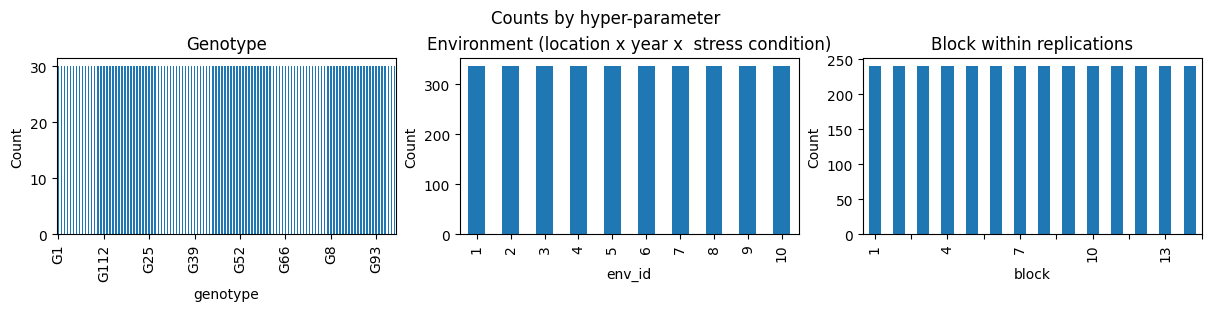

In [4]:
# Basic checks for completeness

fig, axs = plot.fig_axs(nrows=1, ncols=3, figsize=(12, 3), sharex=False)
fig.suptitle("Counts by hyper-parameter")

for ax, (par, title) in zip(
    axs,
    [
        ("genotype", "Genotype"),
        ("env_id", "Environment (location x year x  stress condition)"),
        ("block", "Block within replications"),
    ],
    strict=False,
):
    (
        ms[par]
        .value_counts()
        .sort_index()
        .plot(kind="bar", title=title, ylabel="Count", ax=ax)
    )
    ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
plt.show()

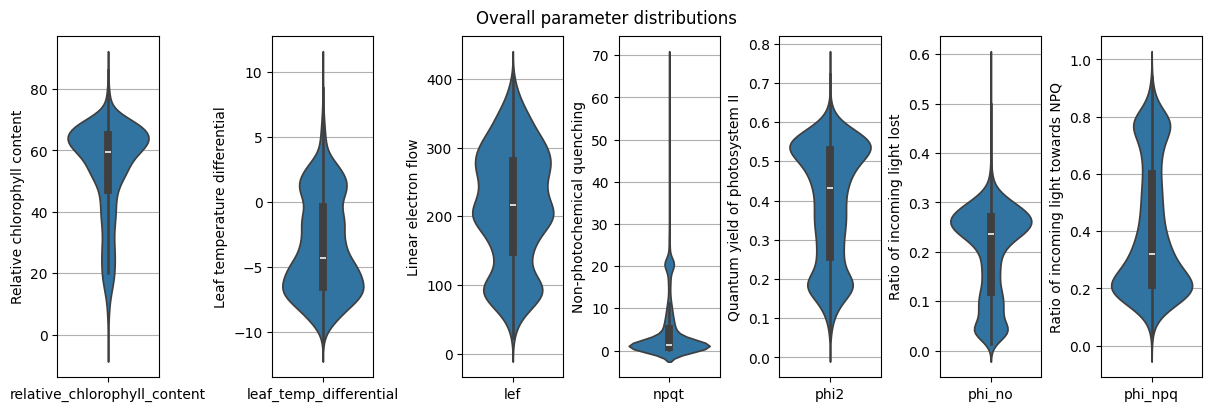

In [5]:
# Overall distributions

fig, axs = plot.fig_axs(nrows=1, ncols=7, figsize=(12, 4), sharex=False)
fig.suptitle("Overall parameter distributions")

for ax, (par, title) in zip(
    axs,
    [
        ("relative_chlorophyll_content", "Relative chlorophyll content"),
        ("leaf_temp_differential", "Leaf temperature differential"),
        ("lef", "Linear electron flow"),
        ("npqt", "Non-photochemical quenching"),
        ("phi2", "Quantum yield of photosystem II"),
        ("phi_no", "Ratio of incoming light lost"),
        ("phi_npq", "Ratio of incoming light towards NPQ"),
    ],
    strict=False,
):
    sns.violinplot(ms.loc[:, [par]], ax=ax)
    ax.set_ylabel(title)
plt.show()

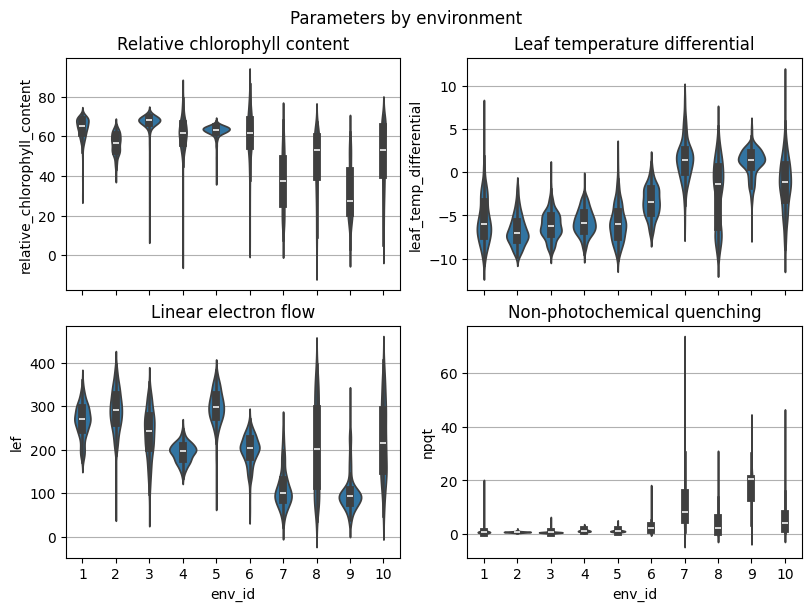

In [6]:
fig, axs = plot.fig_axs(nrows=2, ncols=2, figsize=(8, 6))
fig.suptitle("Parameters by environment")

for ax, (par, title) in zip(
    axs,
    [
        ("relative_chlorophyll_content", "Relative chlorophyll content"),
        ("leaf_temp_differential", "Leaf temperature differential"),
        ("lef", "Linear electron flow"),
        ("npqt", "Non-photochemical quenching"),
        ("phi2", "Quantum yield of photosystem II"),
        ("phi_no", "Ratio of incoming light lost"),
        ("phi_npq", "Ratio of incoming light towards NPQ"),
    ],
    strict=False,
):
    sns.violinplot(
        data=ms,
        x="env_id",
        y=par,
        ax=ax,
    )
    ax.set_title(title)
plt.show()

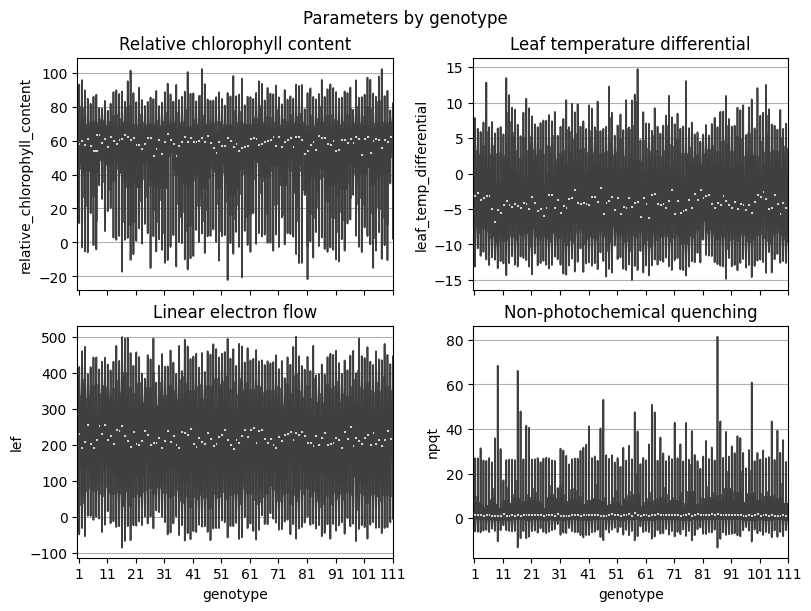

In [7]:
fig, axs = plot.fig_axs(nrows=2, ncols=2, figsize=(8, 6))
fig.suptitle("Parameters by genotype")

data = ms.copy()
data["genotype"] = ms["genotype"].str.slice(1).astype(int)

for ax, (par, title) in zip(
    axs,
    [
        ("relative_chlorophyll_content", "Relative chlorophyll content"),
        ("leaf_temp_differential", "Leaf temperature differential"),
        ("lef", "Linear electron flow"),
        ("npqt", "Non-photochemical quenching"),
        ("phi2", "Quantum yield of photosystem II"),
        ("phi_no", "Ratio of incoming light lost"),
        ("phi_npq", "Ratio of incoming light towards NPQ"),
    ],
    strict=False,
):
    sns.violinplot(
        data=data,
        x="genotype",
        y=par,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticks(np.arange(0, 112, 10))
plt.show()

## Heritability


In [8]:
# Clean up data before analysis
data, env_factors, gtype = drop_na_multiple(
    ms.loc[:, ["lef", "npqt", "phi2", "phi_no", "phi_npq"]],
    ms.loc[:, ["env_id"]],
    ms.loc[:, "genotype"],
)

# Filter out genotypes with fewer than 3 entries
more_than_3 = gtype.groupby(gtype).transform("size") > 3
data = data[more_than_3]
env_factors = env_factors[more_than_3]

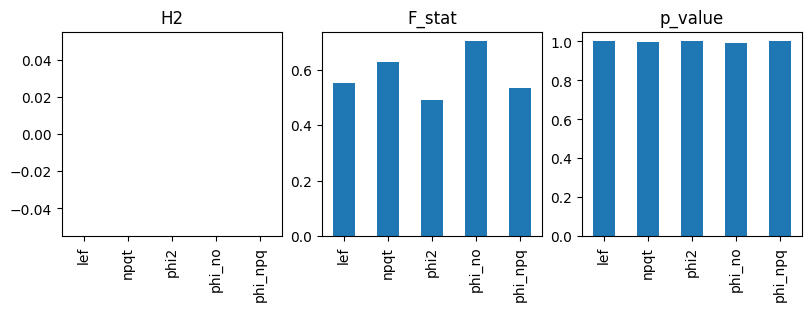

In [9]:
h2 = heritability(
    data=data,
    gtype=gtype,
)

_ = h2.plot()

In [10]:
h2.as_frame()

,H2,F_stat,p_value
lef,0.0,0.551150,0.999960
npqt,0.0,0.627038,0.999158
phi2,0.0,0.490070,0.999998
phi_no,0.0,0.701353,0.992184
phi_npq,0.0,0.532723,0.999984


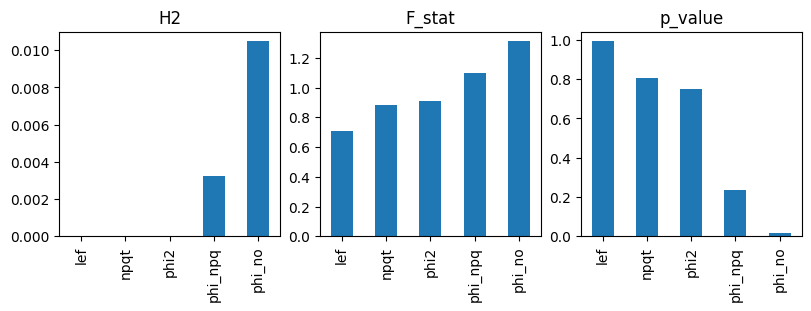

In [11]:
h2_cov = heritability_with_covariates(
    data=data,
    env_factors=env_factors,
    gtype=gtype,
)

_ = h2_cov.plot()

In [12]:
h2_cov.as_frame()

,H2,F_stat,p_value
lef,0.000000,0.705222,0.991373
npqt,0.000000,0.882208,0.804325
phi2,0.000000,0.906497,0.747024
phi_npq,0.003253,1.095531,0.235835
phi_no,0.010478,1.309953,0.017673
